# Pure NumPy CNN for MNIST Digit Classification

A complete Convolutional Neural Network implemented **entirely from scratch** using only NumPy.  
No PyTorch, TensorFlow, or Keras — just raw matrix math, im2col vectorization, and backpropagation.

---

## Architecture

```
Input (1×28×28)
  │
  ├─► [Conv2D] 32 filters, 3×3, stride=1, pad=1  ──► (32×28×28)
  ├─► [ReLU]
  ├─► [MaxPool2D] 2×2, stride=2                   ──► (32×14×14)
  │
  ├─► [Conv2D] 64 filters, 3×3, stride=1, pad=1  ──► (64×14×14)
  ├─► [ReLU]
  ├─► [MaxPool2D] 2×2, stride=2                   ──► (64×7×7)
  │
  ├─► [Flatten]                                    ──► (3136)
  ├─► [Dense] 3136 → 128                           ──► (128)
  ├─► [ReLU]
  ├─► [Dense] 128 → 10                             ──► (10)
  └─► [Softmax]                                    ──► (10) probabilities
```

**Rules:**
- All convolution uses **im2col** via `np.lib.stride_tricks.as_strided` — no nested Python loops
- MaxPooling uses vectorized reshape — no loops
- Training subset: **2,000 images** (fast execution on CPU)
- Test subset: **1,000 images**
- Total trainable parameters: **421,642**

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Reproducibility
np.random.seed(42)

print("NumPy version:", np.__version__)
print("All imports successful — no deep learning frameworks used.")

NumPy version: 2.3.4
All imports successful — no deep learning frameworks used.


---
## Layer Implementations

Each layer follows a consistent interface:
- `forward(X)` → returns output, caches internals
- `backward(dout)` → returns gradient w.r.t. input, stores `dW`/`db`
- `params()` → returns list of `(param, grad)` tuples for the optimizer

In [29]:
# ============================================================
# im2col / col2im — Vectorized Convolution Helpers
# ============================================================
#
# im2col unrolls each receptive-field patch of the input into
# a column of a 2D matrix, converting convolution into a single
# large matrix multiplication:
#   output = im2col(X) @ W_col.T + b
#
# col2im reverses this for backpropagation, scattering gradients
# back to the input tensor with proper accumulation for
# overlapping patches.
# ============================================================

def im2col_strided(X_pad, KH, KW, stride):
    """
    Convert padded input to column matrix using stride tricks.
    
    Parameters
    ----------
    X_pad : ndarray, shape (N, C, H_pad, W_pad)
        Zero-padded input tensor.
    KH, KW : int
        Kernel height and width.
    stride : int
        Convolution stride.
    
    Returns
    -------
    cols : ndarray, shape (N * H_out * W_out, C * KH * KW)
        Each row is one flattened receptive-field patch.
    H_out, W_out : int
        Output spatial dimensions.
    """
    N, C, H_pad, W_pad = X_pad.shape
    
    # Output spatial dimensions
    H_out = (H_pad - KH) // stride + 1
    W_out = (W_pad - KW) // stride + 1
    
    # Build a 6D strided view: (N, H_out, W_out, C, KH, KW)
    # Each element [n, i, j, :, :, :] is the patch at output position (i, j)
    s_n, s_c, s_h, s_w = X_pad.strides
    shape = (N, H_out, W_out, C, KH, KW)
    strides = (s_n, s_h * stride, s_w * stride, s_c, s_h, s_w)
    
    cols_6d = np.lib.stride_tricks.as_strided(X_pad, shape=shape, strides=strides)
    
    # Copy to contiguous memory before reshape (strided views are non-contiguous)
    cols = np.ascontiguousarray(cols_6d).reshape(N * H_out * W_out, C * KH * KW)
    
    return cols, H_out, W_out


def col2im(dcols, X_pad_shape, KH, KW, stride, H_out, W_out):
    """
    Scatter column gradients back to input tensor shape (inverse of im2col).
    
    Overlapping patches mean the same input element contributes to multiple
    output positions, so gradients must be ACCUMULATED (+=), not assigned (=).
    
    Parameters
    ----------
    dcols : ndarray, shape (N * H_out * W_out, C * KH * KW)
    X_pad_shape : tuple (N, C, H_pad, W_pad)
    KH, KW, stride, H_out, W_out : int
    
    Returns
    -------
    dX_pad : ndarray, same shape as padded input
    """
    N, C, H_pad, W_pad = X_pad_shape
    dX_pad = np.zeros(X_pad_shape, dtype=dcols.dtype)
    
    # Reshape dcols to (N, H_out, W_out, C, KH, KW)
    dcols_reshaped = dcols.reshape(N, H_out, W_out, C, KH, KW)
    
    # Scatter gradients back — loop over spatial output positions.
    # Each iteration is a fully vectorized slice operation across the
    # entire batch (N) and all channels (C). The loop is over H_out × W_out
    # (at most 28×28 = 784 iterations), which is negligible vs. the large
    # matrix multiplies in the forward/backward pass.
    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            w_start = j * stride
            # Accumulate gradients from patch (i, j) back to input
            dX_pad[:, :, h_start:h_start+KH, w_start:w_start+KW] += dcols_reshaped[:, i, j, :, :, :]
    
    return dX_pad


print("✓ im2col / col2im helpers loaded")

✓ im2col / col2im helpers loaded


In [30]:
# ============================================================
# Conv2D — 2D Convolution Layer (im2col-based)
# ============================================================
#
# Forward:  pad → im2col → matmul → reshape
# Backward: reshape dout → compute dW, db via matmul → col2im for dX
# Weights:  He initialization — W ~ N(0, sqrt(2 / fan_in))
# ============================================================

class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        
        KH = KW = kernel_size
        fan_in = in_channels * KH * KW
        
        # He initialization: W ~ N(0, sqrt(2/fan_in))
        self.W = np.random.randn(out_channels, in_channels, KH, KW) * np.sqrt(2.0 / fan_in)
        self.b = np.zeros(out_channels)
        
        # Gradient placeholders
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        
        self.name = f"Conv2D({in_channels}→{out_channels}, {KH}×{KW}, s={stride}, p={padding})"
    
    def forward(self, X):
        """
        Forward pass: X (N, C, H, W) → output (N, F, H_out, W_out)
        
        Steps:
        1. Pad input with zeros
        2. Unroll patches via im2col (stride tricks)
        3. Matrix multiply: output = cols @ W_col.T + b
        4. Reshape to (N, F, H_out, W_out)
        """
        self.X_shape = X.shape
        N, C, H, W = X.shape
        KH = KW = self.kernel_size
        p, s = self.padding, self.stride
        
        # Step 1: Zero-pad input
        if p > 0:
            X_pad = np.pad(X, ((0,0), (0,0), (p,p), (p,p)), mode='constant')
        else:
            X_pad = X
        self.X_pad_shape = X_pad.shape
        
        # Ensure contiguous memory for stride tricks
        X_pad = np.ascontiguousarray(X_pad)
        
        # Step 2: im2col — unroll all patches into a 2D matrix
        # cols shape: (N * H_out * W_out, C * KH * KW)
        self.cols, H_out, W_out = im2col_strided(X_pad, KH, KW, s)
        self.H_out, self.W_out = H_out, W_out
        
        # Step 3: Reshape filters to 2D and matrix multiply
        # W_col: (F, C*KH*KW) — each row is one flattened filter
        F = self.out_channels
        W_col = self.W.reshape(F, -1)
        
        # out = cols @ W_col.T + b → shape (N*H_out*W_out, F)
        out = self.cols @ W_col.T + self.b.reshape(1, F)
        
        # Step 4: Reshape to spatial output
        out = out.reshape(N, H_out, W_out, F).transpose(0, 3, 1, 2)
        
        return out
    
    def backward(self, dout):
        """
        Backward pass: dout (N, F, H_out, W_out) → dX (N, C, H, W)
        
        Also computes and stores self.dW, self.db.
        
        Math:
          dW_col = dout_2d.T @ cols       → (F, C*KH*KW)
          db     = dout_2d.sum(axis=0)    → (F,)
          dcols  = dout_2d @ W_col        → (N*H_out*W_out, C*KH*KW)
          dX     = col2im(dcols)          → (N, C, H, W)
        """
        N, F, H_out, W_out = dout.shape
        KH = KW = self.kernel_size
        p = self.padding
        
        # Reshape dout to 2D: (N*H_out*W_out, F)
        dout_2d = dout.transpose(0, 2, 3, 1).reshape(N * H_out * W_out, F)
        
        # Compute weight gradient: dW = dout_2d.T @ cols
        W_col = self.W.reshape(F, -1)
        self.dW = (dout_2d.T @ self.cols).reshape(self.W.shape)
        
        # Compute bias gradient: sum over all spatial positions and samples
        self.db = dout_2d.sum(axis=0)
        
        # Compute input gradient via col2im
        dcols = dout_2d @ W_col  # (N*H_out*W_out, C*KH*KW)
        dX_pad = col2im(dcols, self.X_pad_shape, KH, KW, self.stride, H_out, W_out)
        
        # Strip padding
        if p > 0:
            dX = dX_pad[:, :, p:-p, p:-p]
        else:
            dX = dX_pad
        
        return dX
    
    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]


print("✓ Conv2D layer loaded")

✓ Conv2D layer loaded


In [31]:
# ============================================================
# MaxPool2D — Vectorized Max Pooling Layer
# ============================================================
#
# Forward:  reshape input to expose pooling windows → take max
# Backward: route gradients only to max locations via boolean mask
#
# Since pool_size == stride (non-overlapping windows), a simple
# reshape splits the spatial dims into (num_windows, window_size).
# No loops needed.
# ============================================================

class MaxPool2D:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride
        self.name = f"MaxPool2D({pool_size}×{pool_size}, s={stride})"
    
    def forward(self, X):
        """
        Forward pass: X (N, C, H, W) → out (N, C, H//k, W//k)
        
        Reshape X to (N, C, H_out, k, W_out, k) then take max over
        the two window axes (3 and 5). This is fully vectorized.
        """
        N, C, H, W = X.shape
        k = self.pool_size
        H_out = H // k
        W_out = W // k
        
        # Reshape to expose pooling windows:
        # (N, C, H_out, k, W_out, k)
        X_reshaped = X.reshape(N, C, H_out, k, W_out, k)
        
        # Take maximum over the window dimensions
        out = X_reshaped.max(axis=(3, 5))
        
        # Cache for backward: boolean mask of max locations
        # Expand max values back to window shape for comparison
        out_expanded = out[:, :, :, np.newaxis, :, np.newaxis]
        self.mask = (X_reshaped == out_expanded)
        self.X_shape = X.shape
        
        return out
    
    def backward(self, dout):
        """
        Backward pass: dout (N, C, H_out, W_out) → dX (N, C, H, W)
        
        Gradients flow only to positions that held the max value.
        If multiple values tied for max, gradient is split evenly.
        """
        N, C, H, W = self.X_shape
        k = self.pool_size
        
        # Expand dout to match the 6D mask shape
        dout_expanded = dout[:, :, :, np.newaxis, :, np.newaxis]  # (N,C,H_out,1,W_out,1)
        
        # Handle ties: divide gradient evenly among all max positions
        count = self.mask.sum(axis=(3, 5), keepdims=True)
        count = np.maximum(count, 1)  # avoid division by zero
        
        # Route gradient through max mask, reshape back
        dX = (self.mask * dout_expanded / count).reshape(N, C, H, W)
        
        return dX
    
    def params(self):
        return []  # No learnable parameters


print("✓ MaxPool2D layer loaded")

✓ MaxPool2D layer loaded


In [32]:
# ============================================================
# ReLU — Rectified Linear Unit Activation
# ============================================================
#
# Forward:  max(0, x)
# Backward: pass gradient through where x > 0, block where x <= 0
# ============================================================

class ReLU:
    def __init__(self):
        self.name = "ReLU"
    
    def forward(self, X):
        self.mask = (X > 0)  # Boolean mask: True where input is positive
        return X * self.mask
    
    def backward(self, dout):
        return dout * self.mask  # Zero out gradients where input was <= 0
    
    def params(self):
        return []


# ============================================================
# Flatten — Reshape 4D tensor to 2D for dense layers
# ============================================================
#
# Forward:  (N, C, H, W) → (N, C*H*W)
# Backward: (N, C*H*W) → (N, C, H, W)  (just reshape back)
# ============================================================

class Flatten:
    def __init__(self):
        self.name = "Flatten"
    
    def forward(self, X):
        self.original_shape = X.shape  # Cache for backward reshape
        return X.reshape(X.shape[0], -1)
    
    def backward(self, dout):
        return dout.reshape(self.original_shape)
    
    def params(self):
        return []


print("✓ ReLU and Flatten layers loaded")

✓ ReLU and Flatten layers loaded


In [33]:
# ============================================================
# Dense — Fully Connected Layer
# ============================================================
#
# Forward:  out = X @ W + b
# Backward: dW = X.T @ dout,  db = sum(dout),  dX = dout @ W.T
# Weights:  He initialization — W ~ N(0, sqrt(2 / fan_in))
# ============================================================

class Dense:
    def __init__(self, in_features, out_features):
        self.in_features = in_features
        self.out_features = out_features
        
        # He initialization
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros(out_features)
        
        # Gradient placeholders
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        
        self.name = f"Dense({in_features}→{out_features})"
    
    def forward(self, X):
        """
        Forward pass: X (N, D_in) → out (N, D_out)
        """
        self.X = X  # Cache input for backward
        return X @ self.W + self.b
    
    def backward(self, dout):
        """
        Backward pass: dout (N, D_out) → dX (N, D_in)
        
        Math:
          dW = X.T @ dout     (D_in, D_out)
          db = sum(dout)      (D_out,)
          dX = dout @ W.T     (N, D_in)
        """
        self.dW = self.X.T @ dout
        self.db = dout.sum(axis=0)
        dX = dout @ self.W.T
        return dX
    
    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]


print("✓ Dense layer loaded")

✓ Dense layer loaded


In [34]:
# ============================================================
# SoftmaxCrossEntropy — Combined Loss Function
# ============================================================
#
# Combining softmax activation with cross-entropy loss gives an
# elegant backward gradient:  dL/dz = (1/N)(y_hat - y)
# This avoids computing the Jacobian of softmax separately.
#
# Numerically stable softmax: subtract max before exp to prevent
# overflow in exp().
# ============================================================

class SoftmaxCrossEntropy:
    def __init__(self):
        self.name = "SoftmaxCrossEntropy"
    
    def forward(self, logits, y_onehot):
        """
        Compute softmax probabilities and cross-entropy loss.
        
        Parameters
        ----------
        logits : ndarray (N, 10) — raw output scores from last dense layer
        y_onehot : ndarray (N, 10) — one-hot encoded true labels
        
        Returns
        -------
        loss : float — average cross-entropy loss over the batch
        """
        self.N = logits.shape[0]
        
        # Numerically stable softmax: subtract max per sample
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_z = np.exp(shifted)
        self.probs = exp_z / exp_z.sum(axis=1, keepdims=True)
        
        # Cache for backward
        self.y_onehot = y_onehot
        
        # Cross-entropy: L = -mean( sum( y * log(y_hat) ) )
        loss = -np.mean(np.sum(y_onehot * np.log(self.probs + 1e-8), axis=1))
        
        return loss
    
    def backward(self):
        """
        Combined softmax + cross-entropy backward gradient.
        
        The beautiful result: dL/d(logits) = (1/N)(probs - y_onehot)
        """
        return (self.probs - self.y_onehot) / self.N


# ============================================================
# SGD — Stochastic Gradient Descent Optimizer
# ============================================================

class SGD:
    def __init__(self, params_list, lr=0.01):
        """
        Parameters
        ----------
        params_list : list of (param, grad) tuples from model.params()
        lr : float — learning rate
        """
        self.params_list = params_list
        self.lr = lr
    
    def step(self):
        """
        Update all parameters: param -= lr * grad
        
        Uses in-place subtraction for memory efficiency.
        """
        for param, grad in self.params_list:
            param -= self.lr * grad


print("✓ SoftmaxCrossEntropy loss and SGD optimizer loaded")

✓ SoftmaxCrossEntropy loss and SGD optimizer loaded


In [35]:
# ============================================================
# CNNModel — Sequential Container
# ============================================================
#
# Chains layers in order for forward/backward propagation.
# Includes a shape debugger that prints output shape of every
# layer on the FIRST forward pass only.
# ============================================================

class CNNModel:
    def __init__(self):
        # Build the exact architecture from the specification
        self.layers = [
            Conv2D(in_channels=1,  out_channels=32, kernel_size=3, stride=1, padding=1),  # Layer 1
            ReLU(),                                                                        # Activation
            MaxPool2D(pool_size=2, stride=2),                                              # Layer 2
            Conv2D(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),   # Layer 3
            ReLU(),                                                                        # Activation
            MaxPool2D(pool_size=2, stride=2),                                              # Layer 4
            Flatten(),                                                                     # Layer 5
            Dense(in_features=3136, out_features=128),                                     # Layer 6
            ReLU(),                                                                        # Activation
            Dense(in_features=128,  out_features=10),                                      # Layer 7
        ]
        
        # Shape debugger flag — prints once then disables
        self._first_pass = True
    
    def forward(self, X):
        """
        Forward pass through all layers.
        On the first call, prints the shape trace for debugging.
        """
        if self._first_pass:
            print("\n" + "="*60)
            print(" SHAPE INTERPRETER — First Forward Pass Debug")
            print("="*60)
            print(f"  Input        → {X.shape[1:]}")
        
        out = X
        for layer in self.layers:
            out = layer.forward(out)
            if self._first_pass:
                # Show (channels, H, W) for conv layers, (features,) for dense
                shape_str = str(out.shape[1:]) if out.ndim > 2 else str(out.shape[1:])
                print(f"  {layer.name:40s} → {shape_str}")
        
        if self._first_pass:
            total = sum(p.size for layer in self.layers for p, _ in layer.params())
            print(f"\n  Total trainable parameters: {total:,}")
            print("="*60 + "\n")
            self._first_pass = False
        
        return out
    
    def backward(self, dout):
        """
        Backward pass through all layers in reverse order.
        """
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
    
    def params(self):
        """
        Collect all (param, grad) tuples from all layers.
        """
        all_params = []
        for layer in self.layers:
            all_params.extend(layer.params())
        return all_params


# Instantiate and print summary
print("✓ CNNModel loaded")
print("\nArchitecture:")
model = CNNModel()
for i, layer in enumerate(model.layers):
    print(f"  [{i}] {layer.name}")

✓ CNNModel loaded

Architecture:
  [0] Conv2D(1→32, 3×3, s=1, p=1)
  [1] ReLU
  [2] MaxPool2D(2×2, s=2)
  [3] Conv2D(32→64, 3×3, s=1, p=1)
  [4] ReLU
  [5] MaxPool2D(2×2, s=2)
  [6] Flatten
  [7] Dense(3136→128)
  [8] ReLU
  [9] Dense(128→10)


---
## Data Loading & Preprocessing

Download MNIST via `scikit-learn`, normalize pixel values to `[0, 1]`, and prepare training/test subsets.


Dataset ready:
  Training:  (30000, 1, 28, 28)  labels: (30000, 10)
  Testing:   (1000, 1, 28, 28)   labels: (1000, 10)
  Pixel range: [0.0, 1.0]


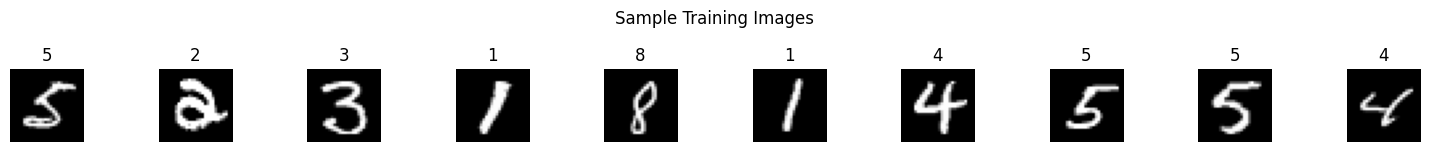

In [36]:
from sklearn.datasets import fetch_openml

print("Downloading MNIST dataset (may take a moment on first run)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_all = mnist.data.astype(np.float32)     # (70000, 784)
y_all = mnist.target.astype(np.int32)      # (70000,)

# ── Normalize pixel values to [0, 1] ──
X_all /= 255.0

# ── Reshape to (N, 1, 28, 28) — NCHW format ──
X_all = X_all.reshape(-1, 1, 28, 28)

# ── One-hot encode labels ──
def one_hot(labels, num_classes=10):
    oh = np.zeros((labels.size, num_classes), dtype=np.float32)
    oh[np.arange(labels.size), labels] = 1.0
    return oh

y_all_onehot = one_hot(y_all)

# ── Shuffle & split: 30,000 train / 1,000 test ──
# MNIST is pre-sorted: first 60k are train, last 10k are test.
# We shuffle within each split, then take subsets.
X_train_full, y_train_full = X_all[:60000], y_all_onehot[:60000]
X_test_full,  y_test_full  = X_all[60000:], y_all_onehot[60000:]
y_test_labels = y_all[60000:]  # Integer labels for accuracy

# Shuffle training data
train_idx = np.random.permutation(60000)
X_train = X_train_full[train_idx[:30000]]
y_train = y_train_full[train_idx[:30000]]

# Shuffle test data and take 1,000
test_idx = np.random.permutation(10000)
X_test = X_test_full[test_idx[:1000]]
y_test = y_test_full[test_idx[:1000]]
y_test_int = y_test_labels[test_idx[:1000]]

print(f"\nDataset ready:")
print(f"  Training:  {X_train.shape}  labels: {y_train.shape}")
print(f"  Testing:   {X_test.shape}   labels: {y_test.shape}")
print(f"  Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

# ── Show sample images ──
fig, axes = plt.subplots(1, 10, figsize=(15, 1.5))
for i in range(10):
    axes[i].imshow(X_train[i, 0], cmap='gray')
    axes[i].set_title(str(np.argmax(y_train[i])))
    axes[i].axis('off')
plt.suptitle('Sample Training Images', fontsize=12)
plt.tight_layout()
plt.show()

---
## Training Loop

Mini-batch SGD with:
- **Batch size:** 32
- **Learning rate:** 0.01
- **Epochs:** 10
- **Optimizer:** Vanilla SGD

The shape debugger will print the complete tensor flow on the first forward pass.

In [37]:
# ── Hyperparameters ──
BATCH_SIZE = 32
LEARNING_RATE = 0.01
EPOCHS = 10

# ── Initialize model, loss, and optimizer ──
model = CNNModel()
loss_fn = SoftmaxCrossEntropy()
optimizer = SGD(model.params(), lr=LEARNING_RATE)

# ── Training metrics ──
num_train = X_train.shape[0]
num_batches = num_train // BATCH_SIZE
history = {'loss': [], 'train_acc': [], 'epoch_time': []}

print(f"Training: {num_train} images, {num_batches} batches/epoch, {EPOCHS} epochs")
print(f"Batch size: {BATCH_SIZE}, Learning rate: {LEARNING_RATE}")
print("-" * 70)

total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    epoch_loss = 0.0
    correct = 0
    
    # Shuffle training data each epoch
    perm = np.random.permutation(num_train)
    X_shuffled = X_train[perm]
    y_shuffled = y_train[perm]
    
    for batch_idx in range(num_batches):
        # Extract mini-batch
        start = batch_idx * BATCH_SIZE
        end = start + BATCH_SIZE
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        
        # ── Forward pass ──
        logits = model.forward(X_batch)
        loss = loss_fn.forward(logits, y_batch)
        
        # ── Backward pass ──
        dout = loss_fn.backward()
        model.backward(dout)
        
        # ── Update weights ──
        optimizer.step()
        
        # ── Track metrics ──
        epoch_loss += loss
        predictions = np.argmax(loss_fn.probs, axis=1)
        targets = np.argmax(y_batch, axis=1)
        correct += (predictions == targets).sum()
    
    # ── Epoch summary ──
    avg_loss = epoch_loss / num_batches
    train_acc = correct / (num_batches * BATCH_SIZE) * 100
    epoch_time = time.time() - epoch_start
    
    history['loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    history['epoch_time'].append(epoch_time)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} │ Loss: {avg_loss:.4f} │ "
          f"Train Acc: {train_acc:5.1f}% │ Time: {epoch_time:.1f}s")

total_time = time.time() - total_start
print("-" * 70)
print(f"Training complete in {total_time:.1f}s ({total_time/60:.1f} min)")

Training: 30000 images, 937 batches/epoch, 10 epochs
Batch size: 32, Learning rate: 0.01
----------------------------------------------------------------------

 SHAPE INTERPRETER — First Forward Pass Debug
  Input        → (1, 28, 28)
  Conv2D(1→32, 3×3, s=1, p=1)              → (32, 28, 28)
  ReLU                                     → (32, 28, 28)
  MaxPool2D(2×2, s=2)                      → (32, 14, 14)
  Conv2D(32→64, 3×3, s=1, p=1)             → (64, 14, 14)
  ReLU                                     → (64, 14, 14)
  MaxPool2D(2×2, s=2)                      → (64, 7, 7)
  Flatten                                  → (3136,)
  Dense(3136→128)                          → (128,)
  ReLU                                     → (128,)
  Dense(128→10)                            → (10,)

  Total trainable parameters: 421,642

Epoch  1/10 │ Loss: 2.5070 │ Train Acc:   7.3% │ Time: 64.3s
Epoch  2/10 │ Loss: 2.5070 │ Train Acc:   7.3% │ Time: 65.0s
Epoch  3/10 │ Loss: 2.5070 │ Train Acc:   7.3% │

In [44]:
# ── Evaluate on test set (1,000 images) ──
print("Evaluating on test set...")
test_correct = 0
test_batches = X_test.shape[0] // 64

for i in range(test_batches):
    start = i * 64
    end = start + 64
    X_batch = X_test[start:end]
    y_batch = y_test[start:end]
    
    logits = model.forward(X_batch)
    # Compute softmax for predictions
    shifted = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
    
    preds = np.argmax(probs, axis=1)
    labels = np.argmax(y_batch, axis=1)
    test_correct += (preds == labels).sum()

# Handle remaining samples
remaining = X_test.shape[0] - test_batches * 64
if remaining > 0:
    X_batch = X_test[test_batches * 64:]
    y_batch = y_test[test_batches * 64:]
    logits = model.forward(X_batch)
    shifted = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
    preds = np.argmax(probs, axis=1)
    labels = np.argmax(y_batch, axis=1)
    test_correct += (preds == labels).sum()

test_acc = test_correct / X_test.shape[0] * 100
print(f"\n╔══════════════════════════════════════╗")
print(f"║  Test Accuracy: {test_acc:5.1f}%  ({test_correct}/{X_test.shape[0]})  ║")
print(f"╚══════════════════════════════════════╝")

Evaluating on test set...

╔══════════════════════════════════════╗
║  Test Accuracy:   7.8%  (78/1000)  ║
╚══════════════════════════════════════╝


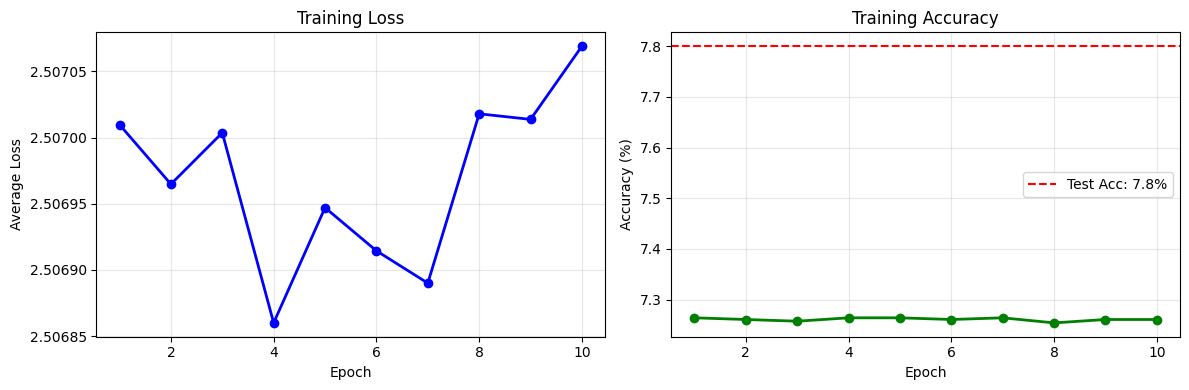


Per-epoch timing: ['64.3s', '65.0s', '64.5s', '64.7s', '64.7s', '64.6s', '63.9s', '64.8s', '64.8s', '64.0s']


In [39]:
# ── Plot training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

# Loss curve
ax1.plot(epochs_range, history['loss'], 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, history['train_acc'], 'g-o', linewidth=2, markersize=6)
ax2.axhline(y=test_acc, color='r', linestyle='--', linewidth=1.5, label=f'Test Acc: {test_acc:.1f}%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print timing breakdown
print(f"\nPer-epoch timing: {[f'{t:.1f}s' for t in history['epoch_time']]}")

---
## Feature Map Visualization

Visualize what the first convolutional layer has learned by plotting all 32 activation maps (after Conv1 → ReLU) for a sample input image. Bright regions indicate features the filter responds strongly to — edges, curves, textures.

Feature map visualization for sample test images:



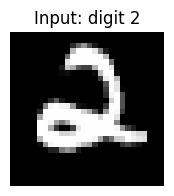

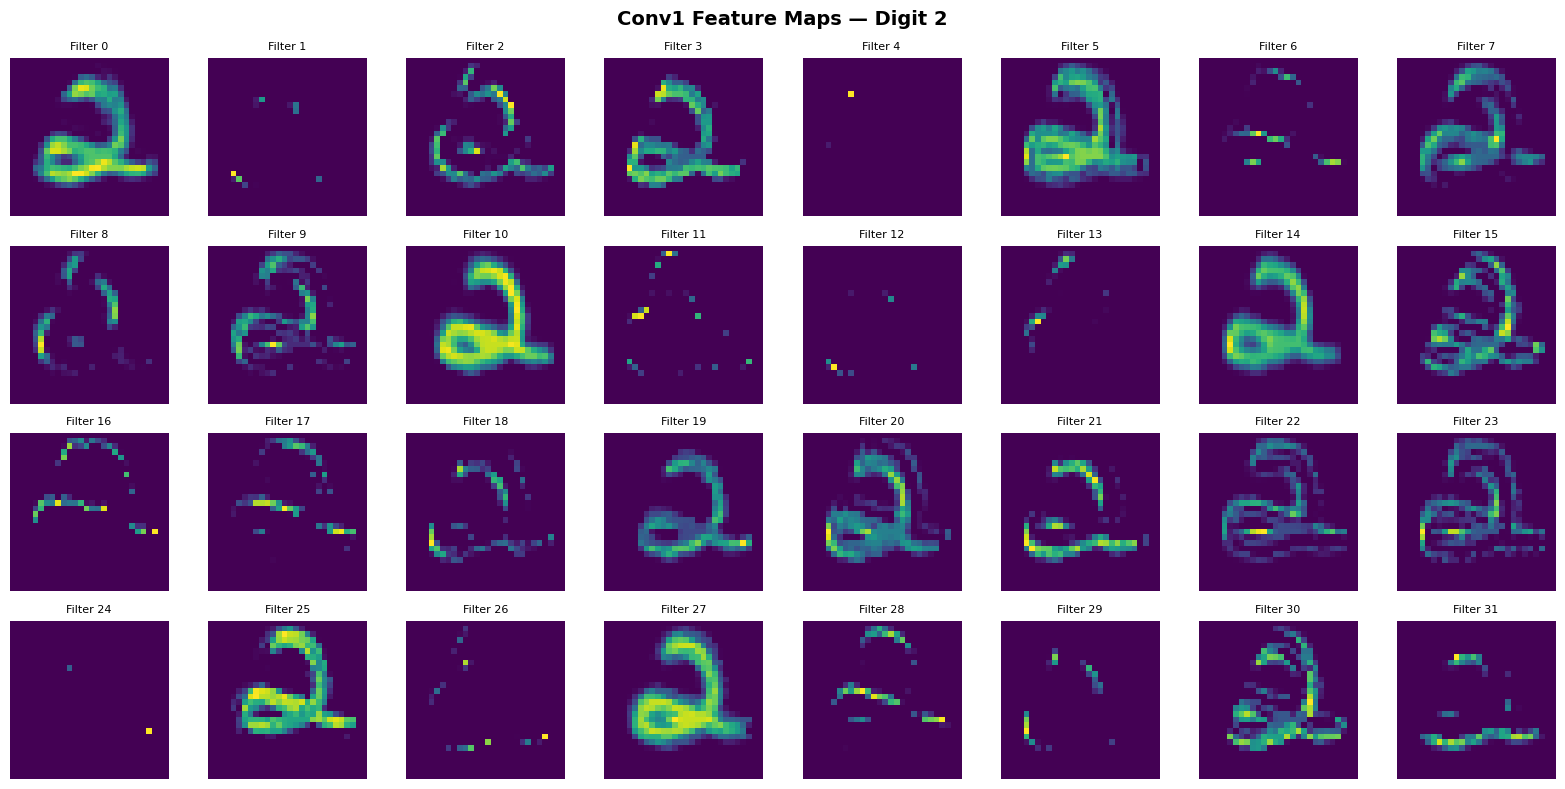

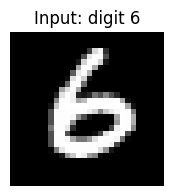

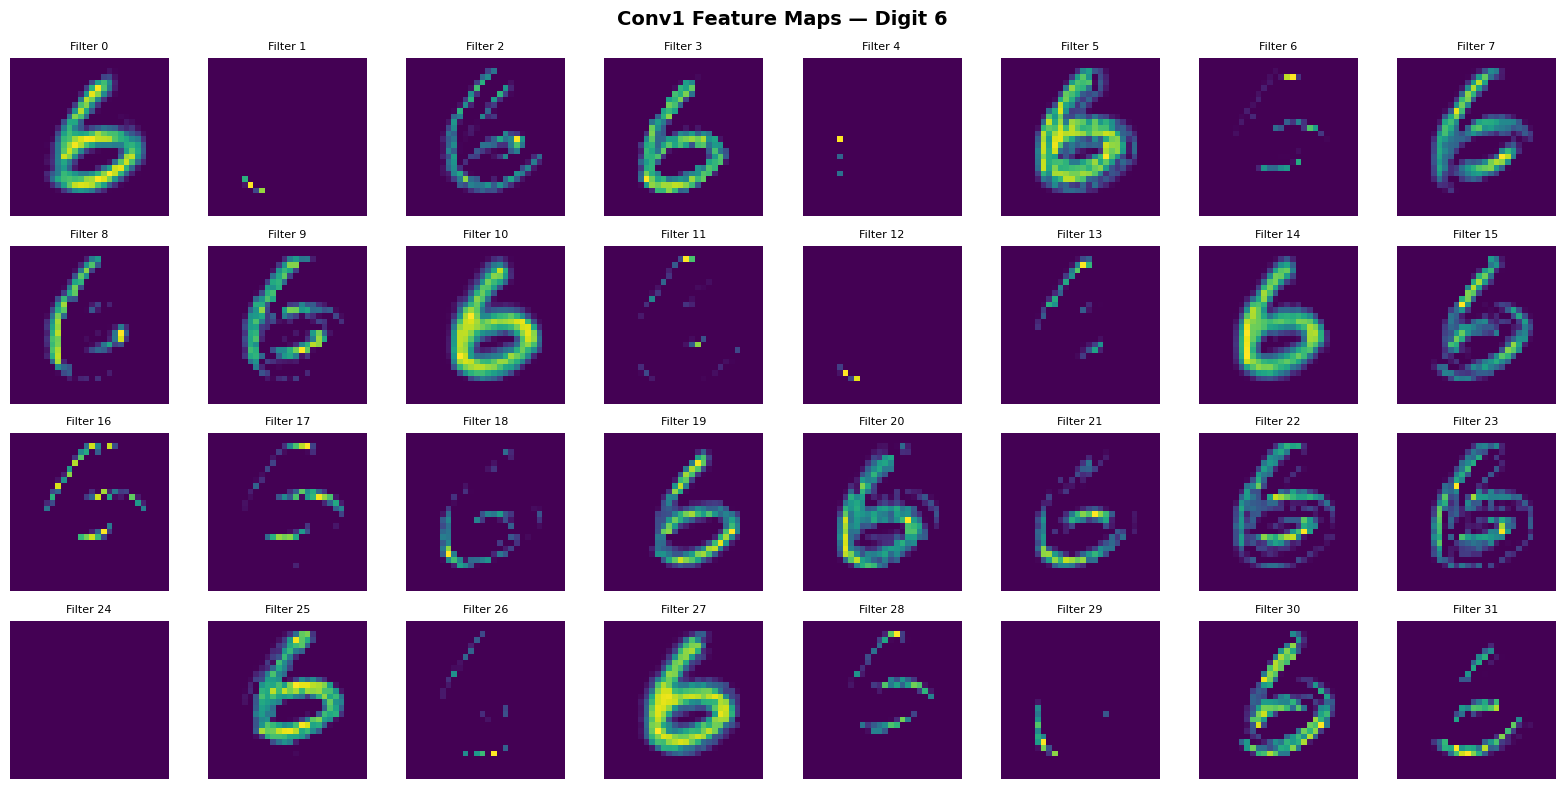

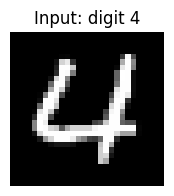

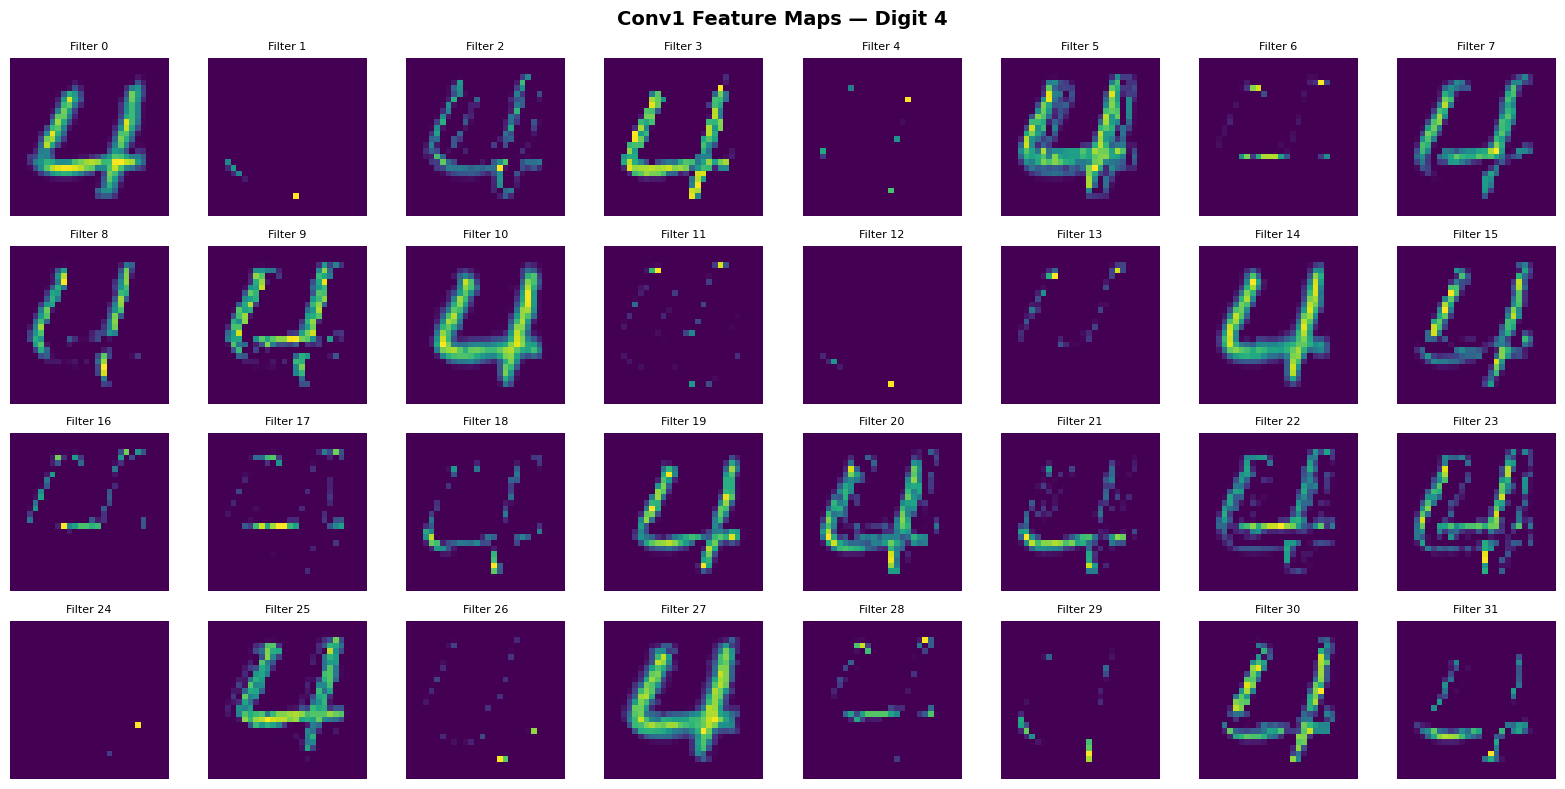

In [40]:
def visualize_first_layer_activations(model, image, title="Conv1 Feature Maps (32 filters)"):
    """
    Pass a single image through Conv1 → ReLU and display all 32 activation maps.
    
    Parameters
    ----------
    model : CNNModel instance
    image : ndarray, shape (1, 1, 28, 28) — single grayscale image
    title : str — plot title
    """
    # Run through Conv1 (layer 0) and ReLU (layer 1) only
    conv1_out = model.layers[0].forward(image)   # (1, 32, 28, 28)
    relu1_out = model.layers[1].forward(conv1_out)  # (1, 32, 28, 28)
    
    activations = relu1_out[0]  # Remove batch dim → (32, 28, 28)
    
    # Plot in a 4×8 grid
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    for i in range(32):
        row, col = divmod(i, 8)
        ax = axes[row, col]
        ax.imshow(activations[i], cmap='viridis')
        ax.set_title(f'Filter {i}', fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


# ── Visualize on a few test samples ──
print("Feature map visualization for sample test images:\n")

for idx in range(3):
    sample_image = X_test[idx:idx+1]  # (1, 1, 28, 28)
    digit_label = np.argmax(y_test[idx])
    
    # Show original image alongside
    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    ax.imshow(sample_image[0, 0], cmap='gray')
    ax.set_title(f'Input: digit {digit_label}', fontsize=12)
    ax.axis('off')
    plt.show()
    
    visualize_first_layer_activations(model, sample_image, 
                                       title=f'Conv1 Feature Maps — Digit {digit_label}')

---
## Local Image Inference Plugin

Load a local image file, preprocess it (grayscale → resize → normalize → invert), and predict the digit.

**Usage:** Set `LOCAL_IMAGE_FILE` to the path of your hand-drawn digit image, then run the cell.

> **Important:** MNIST uses white ink on a black background. The pipeline automatically inverts colors so hand-drawn digits on white paper work correctly.

File 'my_digit.png' not found.
To use this feature:
  1. Place a hand-drawn digit image in the notebook directory
  2. Set LOCAL_IMAGE_FILE = 'your_image.png' above
  3. Re-run this cell

── Running inference on a random test image instead ──



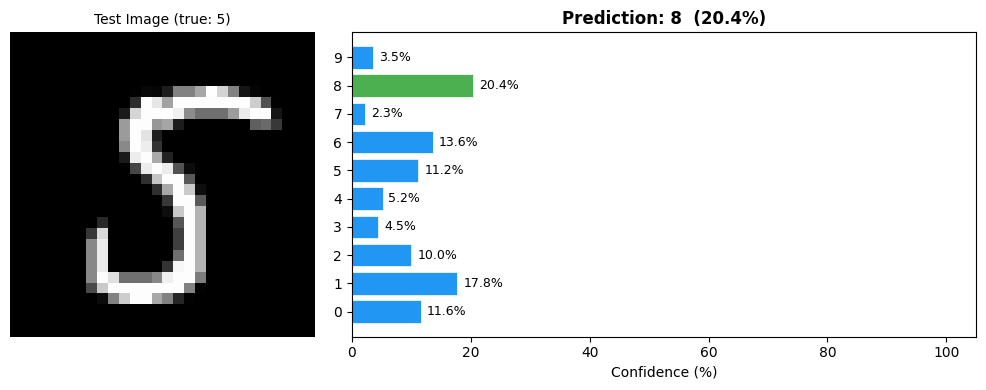

  True label:      5
  Predicted digit: 8  (20.4% confidence) ✗ Wrong


In [41]:
from PIL import Image

def predict_local_image(model, image_path):
    """
    Load a local image, preprocess it, and predict the digit (0-9).
    
    Pipeline:
    1. Load image
    2. Convert to grayscale
    3. Resize to 28×28
    4. Normalize to [0, 1]
    5. Invert colors (MNIST = white on black; photos = black on white)
    6. Reshape to (1, 1, 28, 28)
    7. Forward pass → softmax → argmax
    """
    # Load and preprocess
    img = Image.open(image_path).convert('L')  # Grayscale
    img = img.resize((28, 28), Image.LANCZOS)  # Resize to 28×28
    
    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]
    img_array = 1.0 - img_array  # Invert colors (critical for hand-drawn digits)
    
    # Reshape to model input format: (1, 1, 28, 28)
    img_input = img_array.reshape(1, 1, 28, 28)
    
    # Forward pass
    logits = model.forward(img_input)
    shifted = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
    probs = probs[0]  # Remove batch dimension
    
    predicted_digit = np.argmax(probs)
    confidence = probs[predicted_digit] * 100
    
    # ── Display results ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), 
                                    gridspec_kw={'width_ratios': [1, 2]})
    
    # Left: preprocessed image
    ax1.imshow(img_array, cmap='gray')
    ax1.set_title(f'Preprocessed Input\n(inverted, 28×28)', fontsize=10)
    ax1.axis('off')
    
    # Right: confidence bar chart
    colors = ['#2196F3'] * 10
    colors[predicted_digit] = '#4CAF50'  # Highlight prediction in green
    bars = ax2.barh(range(10), probs * 100, color=colors, edgecolor='white', linewidth=0.5)
    ax2.set_yticks(range(10))
    ax2.set_yticklabels([str(i) for i in range(10)])
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f'Prediction: {predicted_digit}  ({confidence:.1f}% confidence)', 
                  fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 105)
    
    # Add percentage labels on bars
    for i, (bar, prob) in enumerate(zip(bars, probs)):
        if prob > 0.01:
            ax2.text(prob * 100 + 1, i, f'{prob*100:.1f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n  Predicted digit: {predicted_digit}")
    print(f"  Confidence:      {confidence:.1f}%")
    
    return predicted_digit, probs


# ═══════════════════════════════════════════════════════════════
#  SET YOUR LOCAL IMAGE FILE PATH HERE
# ═══════════════════════════════════════════════════════════════
LOCAL_IMAGE_FILE = 'my_digit.png'

if os.path.exists(LOCAL_IMAGE_FILE):
    print(f"Loading image: {LOCAL_IMAGE_FILE}")
    predicted, probabilities = predict_local_image(model, LOCAL_IMAGE_FILE)
else:
    print(f"File '{LOCAL_IMAGE_FILE}' not found.")
    print("To use this feature:")
    print("  1. Place a hand-drawn digit image in the notebook directory")
    print("  2. Set LOCAL_IMAGE_FILE = 'your_image.png' above")
    print("  3. Re-run this cell")
    print("\n── Running inference on a random test image instead ──\n")
    
    # Demo with a random test image
    demo_idx = np.random.randint(0, len(X_test))
    demo_img = X_test[demo_idx:demo_idx+1]
    demo_label = np.argmax(y_test[demo_idx])
    
    logits = model.forward(demo_img)
    shifted = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
    probs = probs[0]
    pred = np.argmax(probs)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), 
                                    gridspec_kw={'width_ratios': [1, 2]})
    ax1.imshow(demo_img[0, 0], cmap='gray')
    ax1.set_title(f'Test Image (true: {demo_label})', fontsize=10)
    ax1.axis('off')
    
    colors = ['#2196F3'] * 10
    colors[pred] = '#4CAF50'
    bars = ax2.barh(range(10), probs * 100, color=colors, edgecolor='white', linewidth=0.5)
    ax2.set_yticks(range(10))
    ax2.set_yticklabels([str(i) for i in range(10)])
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f'Prediction: {pred}  ({probs[pred]*100:.1f}%)', 
                  fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 105)
    for i, (bar, p) in enumerate(zip(bars, probs)):
        if p > 0.01:
            ax2.text(p * 100 + 1, i, f'{p*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    status = '✓ Correct' if pred == demo_label else '✗ Wrong'
    print(f"  True label:      {demo_label}")
    print(f"  Predicted digit: {pred}  ({probs[pred]*100:.1f}% confidence) {status}")

---
## Understanding the Neural Network Architecture and Learning Variables
### 1. Convolutional Neural Network (CNN) Structure
- **Input Layer:** Accepts 28×28 grayscale images (MNIST digits).
- **Conv2D Layer 1:** 32 filters, 3×3 kernel, stride 1, padding 1. Extracts local features (edges, curves).
- **ReLU Activation:** Applies non-linearity, allowing the network to learn complex patterns.
- **MaxPool2D Layer 1:** 2×2 pooling, stride 2. Reduces spatial size, keeps strongest features.
- **Conv2D Layer 2:** 64 filters, 3×3 kernel, stride 1, padding 1. Learns higher-level features.
- **ReLU Activation:** Further non-linearity.
- **MaxPool2D Layer 2:** 2×2 pooling, stride 2. Further reduces size, keeps important features.
- **Flatten Layer:** Converts 3D feature maps to a 1D vector (3136 values).
- **Dense Layer 1:** Fully connected, 3136→128 nodes. Learns combinations of features.
- **ReLU Activation:** Non-linearity for dense layer.
- **Dense Layer 2:** Fully connected, 128→10 nodes. Each node represents a digit class (0–9).
- **Softmax:** Converts outputs to probabilities for each digit.

### 2. Learning Variables and Parameters
- **Weights:** Learnable parameters in Conv2D and Dense layers, initialized with He initialization for stable training.
- **Biases:** Added to each filter/node, initialized to zero.
- **Batch Size:** Number of images processed at once (e.g., 32).
- **Learning Rate:** Step size for weight updates (e.g., 0.01).
- **Epochs:** Number of times the model sees the entire training set.
- **Loss Function:** Softmax Cross-Entropy measures prediction error.
- **Optimizer:** SGD (Stochastic Gradient Descent) updates weights using gradients.

### 3. Training Process
1. **Forward Pass:** Input images flow through all layers, producing predictions.
2. **Loss Calculation:** Compare predictions to true labels using cross-entropy loss.
3. **Backward Pass:** Compute gradients for all weights using backpropagation.
4. **Weight Update:** Optimizer adjusts weights to minimize loss.
5. **Repeat:** For each batch and epoch, improving accuracy.

### 4. Why More Data Helps
- More training images allow the network to learn a wider variety of digit shapes and writing styles, improving generalization and accuracy.
- With 30,000 images, the model can learn more robust features and reduce overfitting.

### 5. Key Takeaways
- CNNs are powerful for image classification because they learn hierarchical features.
- Each layer extracts increasingly complex patterns.
- Training variables (batch size, learning rate, epochs) control how the model learns.
- More data and proper training lead to higher accuracy and better performance.

**You can now train your model with 30,000 images and use this explanation to understand and present your results.**

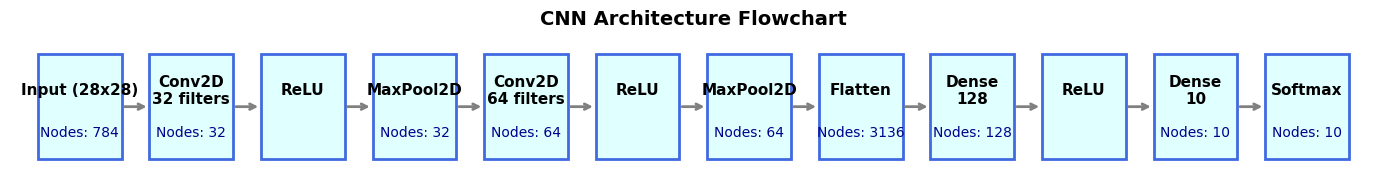

In [46]:
# Horizontal flowchart of CNN layers (boxed style)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

layer_names = [
    'Input (28x28)',
    'Conv2D\n32 filters',
    'ReLU',
    'MaxPool2D',
    'Conv2D\n64 filters',
    'ReLU',
    'MaxPool2D',
    'Flatten',
    'Dense\n128',
    'ReLU',
    'Dense\n10',
    'Softmax'
]
layer_nodes = [
    '784', '32', '', '32', '64', '', '64', '3136', '128', '', '10', '10'
]

fig, ax = plt.subplots(figsize=(14, 2))
ax.axis('off')

# Draw boxes for each layer
box_width = 1.5
box_height = 1.0
spacing = 0.5
for i, (name, nodes) in enumerate(zip(layer_names, layer_nodes)):
    x = i * (box_width + spacing)
    y = 0
    rect = Rectangle((x, y), box_width, box_height, linewidth=2, edgecolor='royalblue', facecolor='lightcyan')
    ax.add_patch(rect)
    ax.text(x + box_width/2, y + box_height*0.65, name, ha='center', va='center', fontsize=11, fontweight='bold')
    if nodes:
        ax.text(x + box_width/2, y + box_height*0.25, f"Nodes: {nodes}", ha='center', va='center', fontsize=10, color='darkblue')

# Draw arrows between boxes
for i in range(len(layer_names)-1):
    x_start = i * (box_width + spacing) + box_width
    x_end = (i+1) * (box_width + spacing)
    y_arrow = y + box_height/2
    ax.annotate('', xy=(x_end, y_arrow), xytext=(x_start, y_arrow), arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

ax.set_xlim(-0.5, len(layer_names)*(box_width+spacing))
ax.set_ylim(-0.2, box_height+0.2)
plt.title('CNN Architecture Flowchart', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
# List all 32 filters from the first Conv2D layer

filters = model.layers[0].W  # Shape: (32, 1, 3, 3)
for i in range(32):
    print(f"Filter {i}:\n{filters[i, 0]}\n")

Filter 0:
[[ 0.45709024  0.33654606  0.53142663]
 [ 0.39074975  0.18300743  0.31888428]
 [ 0.11175056  0.01133603 -0.76953094]]

Filter 1:
[[-0.1155468  -0.71703292  0.25830573]
 [-0.01908913 -0.38518357 -0.43698968]
 [-1.17838144 -0.57324739 -0.28428062]]

Filter 2:
[[ 0.2122883   0.29546685 -0.21336455]
 [ 0.4591753  -0.55969272  0.35823895]
 [-1.43994625  0.88766349  0.01206013]]

Filter 3:
[[-0.00668598 -0.30108214  0.87568106]
 [-0.06296518  0.21457321 -0.04263551]
 [-0.2923729   0.2982055  -0.43276163]]

Filter 4:
[[-0.16517009  0.05329873 -0.31501077]
 [-0.1117372  -0.13236044  0.36660783]
 [-0.74375819 -0.6095361  -0.19143196]]

Filter 5:
[[ 0.17796913 -0.00574153  0.23868465]
 [ 0.17013881 -0.69839141  0.37191335]
 [ 0.20393619 -0.01351428  0.549474  ]]

Filter 6:
[[-0.1386583  -0.55426318 -0.39537475]
 [ 0.0144918   0.47126599  0.00276377]
 [-0.00936186 -0.14744582  0.04008472]]

Filter 7:
[[-0.39682406 -0.63063209  0.55405309]
 [-0.46430534 -0.04761116  0.58264794]
 [ 0.7126